In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [3]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [4]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [5]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_47657/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [6]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [7]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# B - F1

In [8]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [9]:
adata_bf1.obs['clonotype_patient']

sample_index
E30_F1_AAACGGGCAACCGCCA        2_E30
E30_F1_AAAGATGCAAGTTAAG        4_E30
E30_F1_AAAGATGGTACCGGCT        5_E30
E30_F1_AAAGATGTCCACGACG        6_E30
E30_F1_AAAGCAAAGGCAGGTT        7_E30
                             ...    
E29_F1_TTTCCTCTCTAGCACA    44379_E29
E29_F1_TTTGGTTAGAAGCCCA    44380_E29
E29_F1_TTTGGTTAGATAGTCA    43739_E29
E29_F1_TTTGTCACACGAAACG    44382_E29
E29_F1_TTTGTCATCTGGGCCA    43739_E29
Name: clonotype_patient, Length: 37365, dtype: object

In [10]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [11]:
clonotype_counts_b

11840_E25    83
10475_E15    76
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17231_E18     1
17233_E18     1
17235_E18     1
17239_E18     1
9101_E23      1
Name: clonotype_patient, Length: 11248, dtype: int64

In [12]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [13]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [14]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [15]:
clonotype_counts_bf1

,B,F1
11840_E25,83.0,1.0
3931_E31,60.0,2.0
18991_E20,59.0,3.0
12819_E41,45.0,28.0
1610_E21,36.0,142.0
...,...,...
17178_E18,1.0,3.0
17184_E18,1.0,1.0
17152_E18,1.0,1.0
17265_E18,1.0,3.0


In [16]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [17]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [18]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [19]:
len(clonotype_counts_bf1_norm)

1093

In [20]:
len(expanding_clones)

280

In [21]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]

In [22]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

# F1 - F2

In [23]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [24]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [25]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [26]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [27]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [28]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [29]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]

In [30]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [31]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

In [32]:
clonotype_counts_bf1_norm.index

Index(['11840_E25', '3931_E31', '18991_E20', '12819_E41', '1610_E21',
       '16868_E18', '1993_E43', '1592_E21', '9014_E27', '3896_E42',
       ...
       '17320_E18', '16988_E18', '17281_E18', '17296_E18', '17377_E18',
       '17178_E18', '17184_E18', '17152_E18', '17265_E18', '9101_E23'],
      dtype='object', length=1093)

# Proportions

In [33]:
proportions_out_of_f1 = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_bf1_norm.index]).value_counts() / adata[adata.obs['timepoint'] == 'F1'].obs['patient'].value_counts()).fillna(0)})
proportions_out_of_f1['Progression'] = proportions_out_of_f1.index.map(patient_progression)

<Axes: xlabel='Proportion', ylabel='None'>

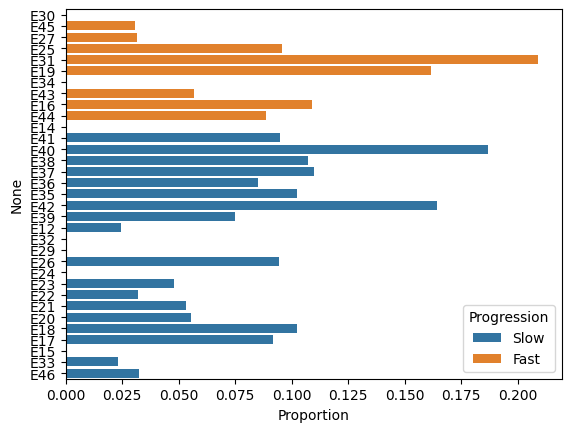

In [34]:
sns.barplot(data=proportions_out_of_f1.sort_values('Progression'),
            x='Proportion',y=proportions_out_of_f1.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])

In [35]:
proportions_out_of_b = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_bf1_norm.index]).value_counts() / adata[adata.obs['timepoint'] == 'B'].obs['patient'].value_counts()).fillna(0)})
proportions_out_of_b['Progression'] = proportions_out_of_b.index.map(patient_progression)

<Axes: xlabel='Proportion', ylabel='None'>

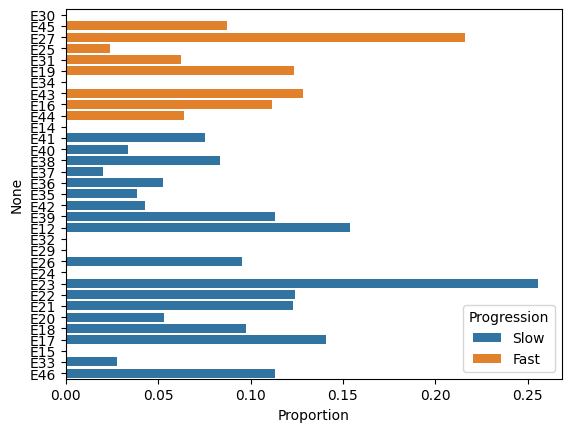

In [36]:
sns.barplot(data=proportions_out_of_b.sort_values('Progression'),
            x='Proportion',y=proportions_out_of_b.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])

In [37]:
proportions = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_bf1_norm.index]).value_counts() / adata[adata.obs['timepoint'].isin(['B','F1'])].obs['patient'].value_counts()).fillna(0)})
proportions['Progression'] = proportions.index.map(patient_progression)

Text(0.5, 1.0, 'Proportion B-F1 shared clones per patient')

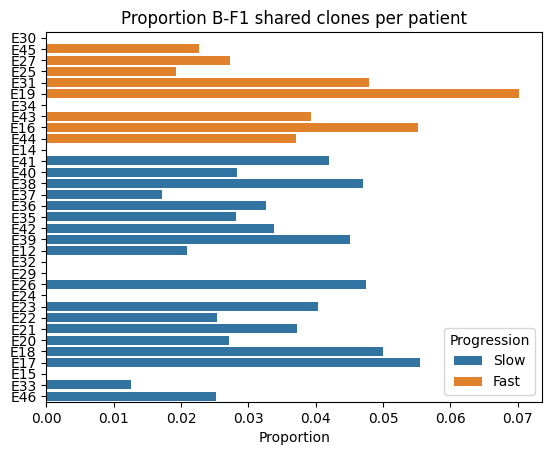

In [38]:
sns.barplot(data=proportions.sort_values('Progression'),
            x='Proportion',y=proportions.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])
plt.ylabel('')
plt.title('Proportion B-F1 shared clones per patient')

In [39]:
proportions_out_of_f1 = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_f1f2_norm.index]).value_counts() / adata[adata.obs['timepoint'] == 'F1'].obs['patient'].value_counts()).fillna(0)})
proportions_out_of_f1['Progression'] = proportions_out_of_f1.index.map(patient_progression)

<Axes: xlabel='Proportion', ylabel='None'>

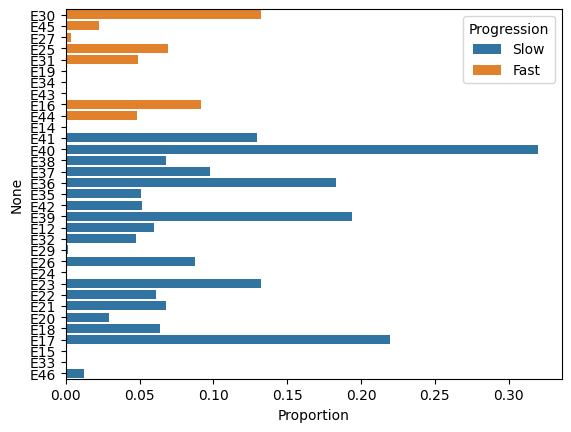

In [40]:
sns.barplot(data=proportions_out_of_f1.sort_values('Progression'),
            x='Proportion',y=proportions_out_of_f1.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])

In [41]:
proportions_out_of_f2 = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_f1f2_norm.index]).value_counts() / adata[adata.obs['timepoint'] == 'F2'].obs['patient'].value_counts()).fillna(0)})
proportions_out_of_f2['Progression'] = proportions_out_of_f2.index.map(patient_progression)

<Axes: xlabel='Proportion', ylabel='None'>

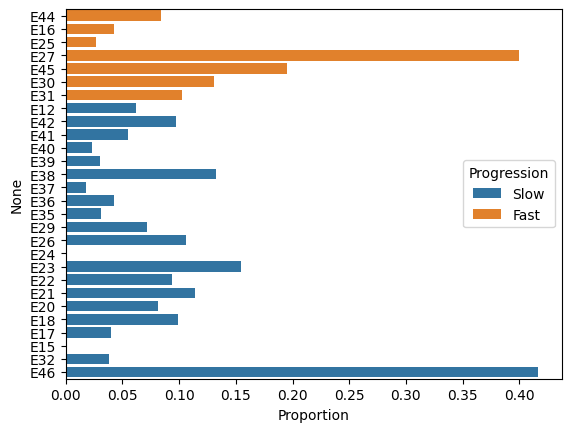

In [42]:
sns.barplot(data=proportions_out_of_f2.sort_values('Progression'),
            x='Proportion',y=proportions_out_of_f2.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])

In [43]:
proportions = pd.DataFrame({
    'Proportion' : (pd.Series([i.split('_')[1] for i in clonotype_counts_f1f2_norm.index]).value_counts() / adata[adata.obs['timepoint'].isin(['F1','F2'])].obs['patient'].value_counts()).fillna(0)})
proportions['Progression'] = proportions.index.map(patient_progression)

Text(0.5, 1.0, 'Proportion F1-F2 shared clones per patient')

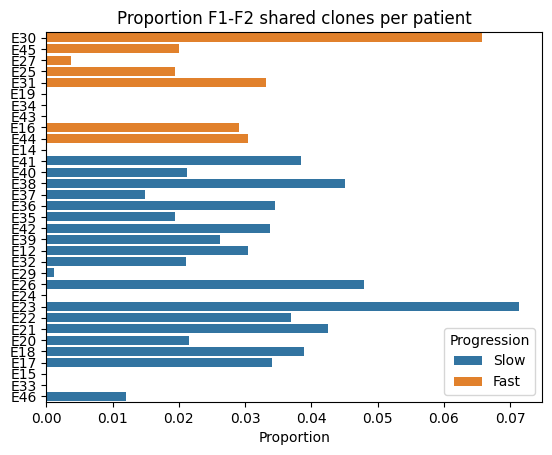

In [44]:
sns.barplot(data=proportions.sort_values('Progression'),
            x='Proportion',y=proportions.sort_values('Progression').index,
            hue='Progression',hue_order=['Slow','Fast'])
plt.ylabel('')
plt.title('Proportion F1-F2 shared clones per patient')